
========== RESULTADO ==========
Melhor rota: [0, 1, 2, 3, 4, 5]
Melhor custo: 8.0

Cálculo da melhor rota:
0 -> 1 = 2.0
1 -> 2 = 1.0
2 -> 3 = 2.0
3 -> 4 = 1.0
4 -> 5 = 2.0


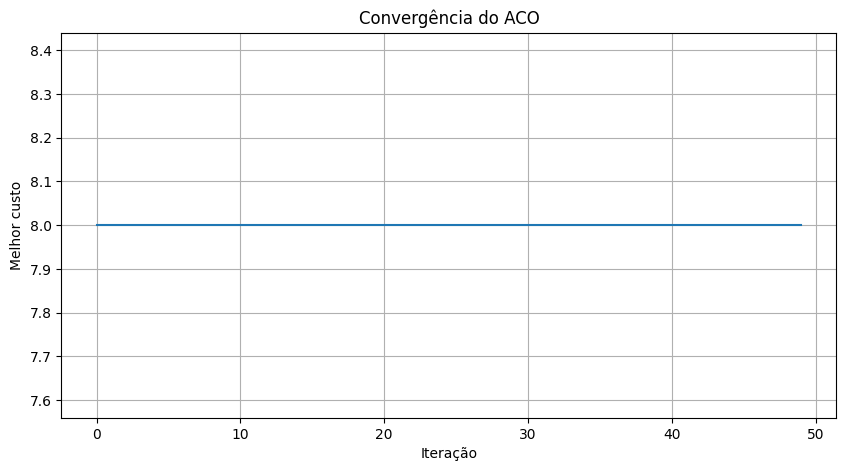


Matriz final de feromônio:
[[  0. 500.   0.   0.   0.   0.]
 [  0.   0. 500.   0.   0.   0.]
 [  0.   0.   0. 500.   0.   0.]
 [  0.   0.   0.   0. 500.   0.]
 [  0.   0.   0.   0.   0. 500.]
 [  0.   0.   0.   0.   0.   0.]]


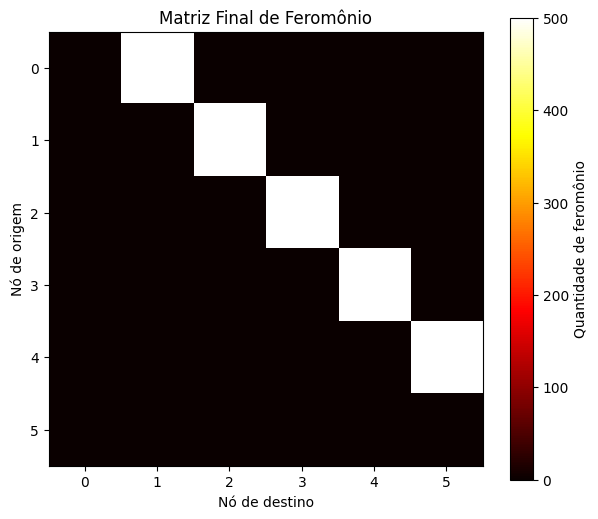

In [1]:
# ============================================================
# LABORATÓRIO 03 — COMPLETANDO O ACO
# Marcação: 147258
# ============================================================

import numpy as np
import random
import matplotlib.pyplot as plt

# ============================================================
# 1. REPRESENTAÇÃO DA REDE
# ============================================================

CUSTOS = np.array([
    [0, 2, 4, np.inf, np.inf, np.inf],
    [2, 0, 1, 5, np.inf, np.inf],
    [4, 1, 0, 2, 3, np.inf],
    [np.inf, 5, 2, 0, 1, 4],
    [np.inf, np.inf, 3, 1, 0, 2],
    [np.inf, np.inf, np.inf, 4, 2, 0]
])

ORIGEM = 0
DESTINO = 5

NUM_FORMIGAS = 20
NUM_ITERACOES = 50

ALPHA = 1.0
BETA = 2.0

TAXA_EVAPORACAO = 0.5
Q = 100

# Semente para deixar o resultado reproduzível
random.seed(42)
np.random.seed(42)

# Matriz inicial de feromônio
feromonio = np.ones_like(CUSTOS, dtype=float)

# Onde não há conexão, não há feromônio
feromonio[CUSTOS == np.inf] = 0

# Remove feromônio da diagonal
np.fill_diagonal(feromonio, 0)


# ============================================================
# 2. FUNÇÃO DE VIZINHOS
# ============================================================

def obter_vizinhos(no):

    vizinhos = []

    for proximo in range(len(CUSTOS)):

        if proximo != no and CUSTOS[no][proximo] != np.inf:
            vizinhos.append(proximo)

    return vizinhos


# ============================================================
# 3. DESAFIO 1 — CALCULAR A ATRATIVIDADE
# ============================================================

def calcular_atratividade(no_atual, proximo):

    fer = feromonio[no_atual][proximo]
    custo = CUSTOS[no_atual][proximo]

    # Fórmula:
    # feromônio^ALPHA × (1/custo)^BETA

    atratividade = (
        (fer ** ALPHA)
        *
        ((1 / custo) ** BETA)
    )

    return atratividade


# ============================================================
# 4. DESAFIO 2 — EVAPORAÇÃO
# ============================================================

def evaporar_feromonio():

    global feromonio

    # Reduz o feromônio existente
    feromonio *= (1 - TAXA_EVAPORACAO)

    # Mantém zero onde não existe conexão
    feromonio[CUSTOS == np.inf] = 0

    # Mantém a diagonal igual a zero
    np.fill_diagonal(feromonio, 0)


# ============================================================
# 5. DESAFIO 3 — DEPÓSITO DE FEROMÔNIO
# ============================================================

def depositar_feromonio(rota, custo):

    # Quanto menor o custo,
    # maior será o depósito
    deposito = Q / custo

    for i in range(len(rota) - 1):

        origem = rota[i]
        destino = rota[i + 1]

        # Adiciona feromônio no caminho utilizado
        feromonio[origem][destino] += deposito


# ============================================================
# FUNÇÃO AUXILIAR — CALCULAR O CUSTO DA ROTA
# ============================================================

def calcular_custo(rota):

    total = 0

    for i in range(len(rota) - 1):

        origem = rota[i]
        destino = rota[i + 1]

        total += CUSTOS[origem][destino]

    return total


# ============================================================
# 6. DESAFIO 4 — CONSTRUIR UMA ROTA
# ============================================================

def construir_rota():

    rota = [ORIGEM]
    atual = ORIGEM

    while atual != DESTINO:

        # Descobre os vizinhos
        vizinhos = obter_vizinhos(atual)

        # Remove nós que já foram visitados
        candidatos = [
            no for no in vizinhos
            if no not in rota
        ]

        if not candidatos:
            return None

        # Calcula a atratividade de cada candidato
        atratividades = [
            calcular_atratividade(
                atual,
                candidato
            )
            for candidato in candidatos
        ]

        # Soma das atratividades
        soma = sum(atratividades)

        # Caso todas sejam zero
        if soma == 0:

            proximo = random.choice(
                candidatos
            )

        else:

            # Transforma em probabilidades
            probabilidades = [
                valor / soma
                for valor in atratividades
            ]

            # Escolhe probabilisticamente
            proximo = random.choices(
                candidatos,
                weights=probabilidades,
                k=1
            )[0]

        rota.append(proximo)

        atual = proximo

    return rota


# ============================================================
# 7. EXECUÇÃO
# ============================================================

melhor_rota = None
melhor_custo = float("inf")

historico = []

for iteracao in range(NUM_ITERACOES):

    rotas = []

    for _ in range(NUM_FORMIGAS):

        rota = construir_rota()

        if rota is not None:

            custo = calcular_custo(
                rota
            )

            rotas.append(
                (rota, custo)
            )

            if custo < melhor_custo:

                melhor_custo = custo

                melhor_rota = rota.copy()

    # Evaporação
    evaporar_feromonio()

    # Depósito de feromônio
    for rota, custo in rotas:

        depositar_feromonio(
            rota,
            custo
        )

    historico.append(
        melhor_custo
    )


# ============================================================
# RESULTADO
# ============================================================

print("\n========== RESULTADO ==========")

print(
    "Melhor rota:",
    melhor_rota
)

print(
    "Melhor custo:",
    melhor_custo
)


# ============================================================
# MOSTRANDO O CÁLCULO DA MELHOR ROTA
# ============================================================

print("\nCálculo da melhor rota:")

for i in range(
    len(melhor_rota) - 1
):

    origem = melhor_rota[i]
    destino = melhor_rota[i + 1]

    print(
        f"{origem} -> {destino} = "
        f"{CUSTOS[origem][destino]}"
    )


# ============================================================
# GRÁFICO DE CONVERGÊNCIA
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(historico)

plt.xlabel("Iteração")
plt.ylabel("Melhor custo")

plt.title(
    "Convergência do ACO"
)

plt.grid()

plt.show()


# ============================================================
# MATRIZ FINAL DE FEROMÔNIO
# ============================================================

print(
    "\nMatriz final de feromônio:"
)

print(
    np.round(
        feromonio,
        2
    )
)

plt.figure(
    figsize=(7, 6)
)

plt.imshow(
    feromonio,
    cmap="hot"
)

plt.colorbar(
    label="Quantidade de feromônio"
)

plt.xlabel(
    "Nó de destino"
)

plt.ylabel(
    "Nó de origem"
)

plt.title(
    "Matriz Final de Feromônio"
)

plt.xticks(
    range(len(CUSTOS))
)

plt.yticks(
    range(len(CUSTOS))
)

plt.show()